# Object Detection using EfficientDet


In [90]:
import os
import json
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import matplotlib.patches as patches

import albumentations as A

from effdet import (
    get_efficientdet_config,
    EfficientDet,
    DetBenchTrain,
    DetBenchPredict
)
from effdet.efficientdet import HeadNet
from torch.utils.tensorboard import SummaryWriter
from torchmetrics.classification import MulticlassAveragePrecision


## 1. Environment and Dataset Setup


In [91]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
DATASET_ROOT = "COCO-based_COCO"

TRAIN_IMAGE_DIR = os.path.join(DATASET_ROOT, "images/train")
VAL_IMAGE_DIR   = os.path.join(DATASET_ROOT, "images/val")

TRAIN_ANN_FILE = os.path.join(DATASET_ROOT, "annotations/train.json")
VAL_ANN_FILE   = os.path.join(DATASET_ROOT, "annotations/val.json")


Device: cpu


In [92]:
CLASS_NAMES = {
    1: "Blind Spot Mirror (Convex Mirror)",
    2: "No Entry (One Way)",
    3: "No Through Road (T-Sign)",
    4: "Pedestrian Crossing (Zebra Crossing)",
    5: "Roundabout Ahead",
    6: "Stop"
}

NUM_CLASSES = len(CLASS_NAMES)
print("Number of classes:", NUM_CLASSES)


Number of classes: 6


In [93]:
train_aug = A.Compose(
    [
        A.HorizontalFlip(p=0.5),
        A.ShiftScaleRotate(
            shift_limit=0.1,
            scale_limit=0.4,
            rotate_limit=15,
            border_mode=cv2.BORDER_CONSTANT,
            p=0.9
        ),
        A.RandomBrightnessContrast(p=0.7),
        A.ColorJitter(p=0.5),
    ],
    bbox_params=A.BboxParams(
        format="pascal_voc",
        label_fields=["labels"],
        min_visibility=0.3
    )
)


## 2. Model and Dataset Definition


In [94]:
class EfficientDetDataset(Dataset):
    def __init__(self, ann_file, image_dir, image_size, augment=False):
        self.image_dir = image_dir
        self.image_size = image_size
        self.augment = augment

        with open(ann_file, "r") as f:
            coco = json.load(f)

        self.images = coco["images"]
        self.annotations = coco["annotations"]

        self.img_to_anns = {}
        for ann in self.annotations:
            self.img_to_anns.setdefault(ann["image_id"], []).append(ann)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        info = self.images[idx]
        path = os.path.join(self.image_dir, info["file_name"])

        image = cv2.imread(path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        anns = self.img_to_anns.get(info["id"], [])
        boxes, labels = [], []

        for ann in anns:
            x, y, w, h = ann["bbox"]
            boxes.append([x, y, x + w, y + h])
            labels.append(ann["category_id"])  # already 1â€“6

        if self.augment and len(boxes) > 0:
            augmented = train_aug(image=image, bboxes=boxes, labels=labels)
            image = augmented["image"]
            boxes = augmented["bboxes"]
            labels = augmented["labels"]

        # resize & pad
        image = image.astype(np.float32) / 255.0
        h, w, _ = image.shape
        th, tw = self.image_size

        scale = min(th / h, tw / w)
        nh, nw = int(h * scale), int(w * scale)

        image = cv2.resize(image, (nw, nh))
        padded = np.zeros((th, tw, 3), dtype=np.float32)
        padded[:nh, :nw] = image

        image_tensor = torch.tensor(padded).permute(2, 0, 1)

        scaled_boxes = [
            [b[0]*scale, b[1]*scale, b[2]*scale, b[3]*scale]
            for b in boxes
        ]

        if len(scaled_boxes) == 0:
            boxes_t = torch.zeros((0,4))
            labels_t = torch.zeros((0,), dtype=torch.int64)
        else:
            boxes_t = torch.tensor(scaled_boxes, dtype=torch.float32)
            labels_t = torch.tensor(labels, dtype=torch.int64)

        return image_tensor, {"boxes": boxes_t, "labels": labels_t}


In [95]:
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(1,3,1,1)
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225]).view(1,3,1,1)

def effdet_collate_fn(batch):
    images, targets = zip(*batch)
    images = torch.stack(images)
    images = (images - IMAGENET_MEAN) / IMAGENET_STD

    max_n = max(t["boxes"].shape[0] for t in targets)

    batch_boxes, batch_labels = [], []

    for t in targets:
        boxes, labels = t["boxes"], t["labels"]
        pad = max_n - boxes.shape[0]

        if pad > 0:
            boxes = torch.cat([boxes, torch.zeros((pad,4))])
            labels = torch.cat([labels, torch.full((pad,), -1)])

        batch_boxes.append(boxes)
        batch_labels.append(labels)

    return images, {
        "bbox": torch.stack(batch_boxes),
        "cls": torch.stack(batch_labels)
    }


## 3. Training and Evaluation


In [96]:
config = get_efficientdet_config("tf_efficientdet_d0")
config.image_size = (512, 512)
config.num_classes = NUM_CLASSES
config.anchor_match_threshold = 0.3  # relaxed, small data

model = EfficientDet(config, pretrained_backbone=True)
model.class_net = HeadNet(config, num_outputs=NUM_CLASSES)

# head-only training (repo default)
for p in model.backbone.parameters():
    p.requires_grad = False

model = DetBenchTrain(model).to(device)

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4
)


INFO:timm.models._builder:Loading pretrained weights from Hugging Face hub (timm/tf_efficientnet_b0.ns_jft_in1k)
INFO:httpx:HTTP Request: HEAD https://huggingface.co/timm/tf_efficientnet_b0.ns_jft_in1k/resolve/main/model.safetensors "HTTP/1.1 302 Found"
INFO:timm.models._hub:[timm/tf_efficientnet_b0.ns_jft_in1k] Safe alternative available for 'pytorch_model.bin' (as 'model.safetensors'). Loading weights using safetensors.


In [97]:
train_dataset = EfficientDetDataset(
    TRAIN_ANN_FILE,
    TRAIN_IMAGE_DIR,
    config.image_size,
    augment=True
)

val_dataset = EfficientDetDataset(
    VAL_ANN_FILE,
    VAL_IMAGE_DIR,
    config.image_size,
    augment=False
)

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    collate_fn=effdet_collate_fn
)


In [98]:
for p in model.model.backbone.parameters():
    p.requires_grad = False
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=2e-4
)

In [99]:
from collections import Counter
import json

with open("COCO-based_COCO/annotations/train.json","r") as f:
    coco = json.load(f)

counts = Counter(ann["category_id"] for ann in coco["annotations"])
for cid,count in counts.items():
    print(cid, count)


2 186
6 128
4 139
1 105
5 93
3 61


In [100]:
from collections import defaultdict
import random

# Build image_id -> class mapping
image_to_class = {}
for ann in coco["annotations"]:
    image_to_class[ann["image_id"]] = ann["category_id"]

# Group image indices by class
class_to_indices = defaultdict(list)
for idx, img in enumerate(coco["images"]):
    img_id = img["id"]
    if img_id in image_to_class:
        class_to_indices[image_to_class[img_id]].append(idx)

# Compute target count (max class)
max_count = max(len(v) for v in class_to_indices.values())
print("Target samples per class:", max_count)

# Oversample minority classes
balanced_indices = []
for cls, indices in class_to_indices.items():
    reps = max_count // len(indices)
    remainder = max_count % len(indices)

    balanced_indices.extend(indices * reps)
    balanced_indices.extend(random.sample(indices, remainder))

print("Balanced dataset size:", len(balanced_indices))


Target samples per class: 124
Balanced dataset size: 744


In [101]:
balanced_train_dataset = torch.utils.data.Subset(
    train_dataset,
    balanced_indices
)

balanced_train_loader = DataLoader(
    balanced_train_dataset,
    batch_size=4,
    shuffle=True,
    collate_fn=effdet_collate_fn
)


In [102]:
from collections import Counter

check_counts = Counter()
for idx in balanced_indices:
    img_id = coco["images"][idx]["id"]
    cls = image_to_class[img_id]
    check_counts[cls] += 1

print("Balanced class counts:")
for cid, name in CLASS_NAMES.items():
    print(f"{name:<40}: {check_counts[cid]}")


Balanced class counts:
Blind Spot Mirror (Convex Mirror)       : 124
No Entry (One Way)                      : 124
No Through Road (T-Sign)                : 124
Pedestrian Crossing (Zebra Crossing)    : 124
Roundabout Ahead                        : 124
Stop                                    : 124


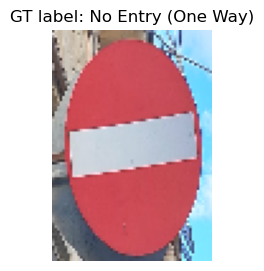

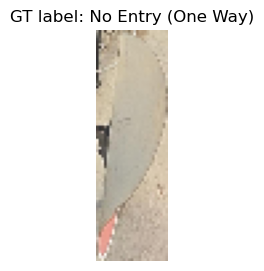

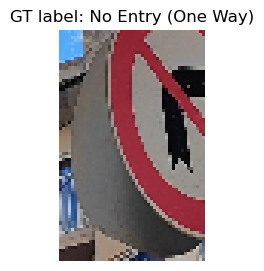

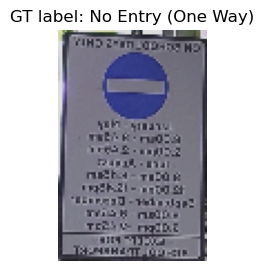

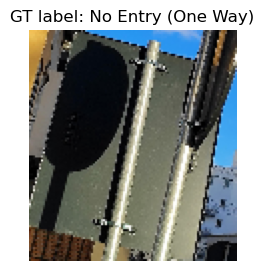

In [103]:
import matplotlib.pyplot as plt

for i in range(5):
    img, tgt = train_dataset[i]

    box = tgt["boxes"][0].int()
    x1, y1, x2, y2 = box

    crop = img[:, y1:y2, x1:x2]

    plt.figure(figsize=(3,3))
    plt.imshow(crop.permute(1,2,0))
    plt.title(f"GT label: {CLASS_NAMES[tgt['labels'][0].item()]}")
    plt.axis("off")
    plt.show()


In [104]:
import torch
import torch.nn.functional as F
from torchvision.models import resnet18
from torchvision.transforms.functional import resize

# --------------------------------
# Prepare tiny fixed subset (MULTI-CLASS)
# IMPORTANT: pick 1 image PER CLASS if possible
# --------------------------------
indices = []
seen = set()
for i, (_, tgt) in enumerate(train_dataset):
    cls = tgt["labels"][0].item()
    if cls not in seen:
        indices.append(i)
        seen.add(cls)
    if len(seen) == NUM_CLASSES:
        break

subset = [train_dataset[i] for i in indices]
print("Using classes:", [CLASS_NAMES[t[1]["labels"][0].item()] for t in subset])

# --------------------------------
# Backbone (FROZEN)
# --------------------------------
backbone = resnet18(pretrained=True)
backbone.fc = torch.nn.Identity()
backbone = backbone.to(device)
backbone.eval()  # VERY IMPORTANT

# --------------------------------
# Linear classifier ONLY
# --------------------------------
linear = torch.nn.Linear(512, NUM_CLASSES).to(device)
optimizer = torch.optim.Adam(linear.parameters(), lr=1e-2)

# --------------------------------
# Overfit loop
# --------------------------------
for epoch in range(50):
    total = 0

    for img, tgt in subset:
        x1, y1, x2, y2 = tgt["boxes"][0].int()
        crop = img[:, y1:y2, x1:x2]

        if crop.shape[1] < 10 or crop.shape[2] < 10:
            continue

        crop = resize(crop, [224, 224]).unsqueeze(0).to(device)

        with torch.no_grad():
            feat = backbone(crop)  # [1, 512]

        label = tgt["labels"][0].item() - 1
        label = torch.tensor([label]).to(device)

        out = linear(feat)
        loss = F.cross_entropy(out, label)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total += loss.item()

    if epoch % 5 == 0:
        print(f"[LINEAR OVERFIT] Epoch {epoch:02d} | Loss {total:.4f}")


Using classes: ['No Entry (One Way)', 'Stop', 'Pedestrian Crossing (Zebra Crossing)', 'Blind Spot Mirror (Convex Mirror)', 'Roundabout Ahead', 'No Through Road (T-Sign)']
[LINEAR OVERFIT] Epoch 00 | Loss 60.0399
[LINEAR OVERFIT] Epoch 05 | Loss 0.0215
[LINEAR OVERFIT] Epoch 10 | Loss 0.0109
[LINEAR OVERFIT] Epoch 15 | Loss 0.0057
[LINEAR OVERFIT] Epoch 20 | Loss 0.0039
[LINEAR OVERFIT] Epoch 25 | Loss 0.0029
[LINEAR OVERFIT] Epoch 30 | Loss 0.0023
[LINEAR OVERFIT] Epoch 35 | Loss 0.0019
[LINEAR OVERFIT] Epoch 40 | Loss 0.0016
[LINEAR OVERFIT] Epoch 45 | Loss 0.0014



=== LINEAR PROBE OVERFIT VISUALISATION ===


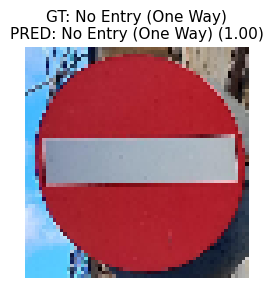

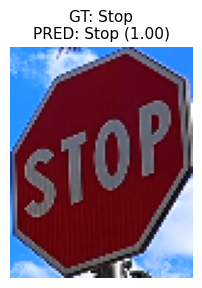

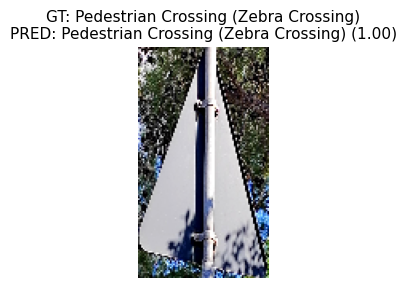

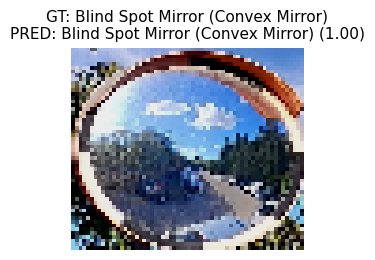

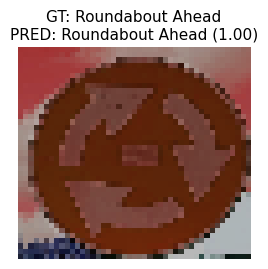

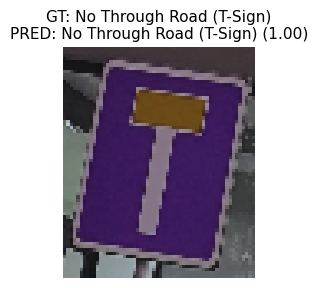

In [105]:
import torch.nn.functional as F
import matplotlib.pyplot as plt

linear.eval()
backbone.eval()

print("\n=== LINEAR PROBE OVERFIT VISUALISATION ===")

for img, tgt in subset:
    # Crop GT box
    x1, y1, x2, y2 = tgt["boxes"][0].int()
    crop = img[:, y1:y2, x1:x2]

    if crop.shape[1] < 10 or crop.shape[2] < 10:
        continue

    # Resize for backbone
    crop_resized = torch.nn.functional.interpolate(
        crop.unsqueeze(0),
        size=(224, 224),
        mode="bilinear",
        align_corners=False
    ).to(device)

    # Forward pass
    with torch.no_grad():
        feat = backbone(crop_resized)
        logits = linear(feat)
        probs = F.softmax(logits, dim=1)
        pred = probs.argmax(dim=1).item()
        conf = probs.max().item()

    gt_label = tgt["labels"][0].item() - 1

    # Plot
    plt.figure(figsize=(3, 3))
    plt.imshow(crop.permute(1, 2, 0).cpu().numpy())
    plt.title(
        f"GT: {CLASS_NAMES[gt_label+1]}\n"
        f"PRED: {CLASS_NAMES[pred+1]} ({conf:.2f})",
        fontsize=11
    )
    plt.axis("off")
    plt.show()


In [ ]:
from effdet import get_efficientdet_config, EfficientDet
import torch.nn as nn

config = get_efficientdet_config("tf_efficientdet_d0")
config.image_size = (512, 512)
config.num_classes = NUM_CLASSES  # required, even if not used

effdet = EfficientDet(config, pretrained_backbone=True)

effdet.class_net = nn.Identity()
effdet.box_net = nn.Identity()

effdet = effdet.to(device)
effdet.eval()  # IMPORTANT: freeze everything

print("EfficientDet backbone ready")

INFO:timm.models._builder:Loading pretrained weights from Hugging Face hub (timm/tf_efficientnet_b0.ns_jft_in1k)
INFO:httpx:HTTP Request: HEAD https://huggingface.co/timm/tf_efficientnet_b0.ns_jft_in1k/resolve/main/model.safetensors "HTTP/1.1 302 Found"
INFO:timm.models._hub:[timm/tf_efficientnet_b0.ns_jft_in1k] Safe alternative available for 'pytorch_model.bin' (as 'model.safetensors'). Loading weights using safetensors.


EfficientDet backbone ready


In [107]:
import torch.nn.functional as F

class EfficientDetFeatureExtractor(nn.Module):
    def __init__(self, effdet):
        super().__init__()
        self.backbone = effdet.backbone
        self.fpn = effdet.fpn

    def forward(self, x):
        feats = self.backbone(x)
        feats = self.fpn(feats)

        pooled = []
        for f in feats:
            pooled.append(F.adaptive_avg_pool2d(f, 1).flatten(1))

        return torch.cat(pooled, dim=1)

feature_extractor = EfficientDetFeatureExtractor(effdet).to(device)
feature_extractor.eval()


EfficientDetFeatureExtractor(
  (backbone): EfficientNetFeatures(
    (conv_stem): Conv2dSame(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
    (bn1): BatchNormAct2d(
      32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): SiLU(inplace=True)
    )
    (blocks): Sequential(
      (0): Sequential(
        (0): DepthwiseSeparableConv(
          (conv_dw): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (bn1): BatchNormAct2d(
            32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
            (drop): Identity()
            (act): SiLU(inplace=True)
          )
          (aa): Identity()
          (se): SqueezeExcite(
            (conv_reduce): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (act1): SiLU(inplace=True)
            (conv_expand): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (gate): Sigmoid()
          )
         

In [116]:
from torchvision.transforms.functional import resize

class EfficientDetGTCropDataset(torch.utils.data.Dataset):
    def __init__(self, det_dataset):
        self.det_dataset = det_dataset

    def __len__(self):
        return len(self.det_dataset)

    def __getitem__(self, idx):
        img, tgt = self.det_dataset[idx]

        x1, y1, x2, y2 = tgt["boxes"][0].int()
        crop = img[:, y1:y2, x1:x2]

        if crop.shape[1] < 10 or crop.shape[2] < 10:
            return self.__getitem__((idx + 1) % len(self))

        crop = resize(crop, [512, 512])
        label = tgt["labels"][0].item() - 1

        return crop, label

In [117]:
train_cls_ds = EfficientDetGTCropDataset(train_dataset)
val_cls_ds   = EfficientDetGTCropDataset(val_dataset)

train_loader = DataLoader(train_cls_ds, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_cls_ds, batch_size=16, shuffle=False)


In [ ]:
import torch
import torch.nn as nn

# HARD SANITY CHECKS

assert "feature_extractor" in globals(), "feature_extractor is NOT defined"
assert "NUM_CLASSES" in globals(), "NUM_CLASSES is NOT defined"
assert "device" in globals(), "device is NOT defined"

print("feature_extractor found")
print("NUM_CLASSES =", NUM_CLASSES)
print("device =", device)


# Infer feature dimension

feature_extractor.eval()

with torch.no_grad():
    dummy = torch.zeros(1, 3, 512, 512).to(device)
    feats = feature_extractor(dummy)
    feat_dim = feats.shape[1]

print("EfficientDet feature dimension:", feat_dim)

# DEFINE CLASSIFIER

classifier = nn.Linear(feat_dim, NUM_CLASSES).to(device)

print("classifier successfully created")
print(classifier)

âœ… feature_extractor found
âœ… NUM_CLASSES = 6
âœ… device = cpu
âœ… EfficientDet feature dimension: 320
âœ… classifier successfully created
Linear(in_features=320, out_features=6, bias=True)


In [119]:
optimizer = torch.optim.Adam(classifier.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()
writer = SummaryWriter('runs/efficientdet-cls')

EPOCHS = 30

for epoch in range(EPOCHS):
    classifier.train()
    total_loss = 0
    correct = 0
    total = 0

    for crops, labels in train_loader:
        crops = crops.to(device)
        labels = labels.to(device)

        with torch.no_grad():
            feats = feature_extractor(crops)

        logits = classifier(feats)
        metric.update(logits, labels)
        loss = criterion(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * crops.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    avg_loss = total_loss / total
    avg_acc = 100 * correct / total
    writer.add_scalar('Loss/train', avg_loss, epoch)
    writer.add_scalar('Accuracy/train', avg_acc, epoch)
    mAP = metric.compute().item() * 100
    writer.add_scalar('mAP/train', mAP, epoch)
    metric.reset()

    print(
        f'[EFFICIENTDET-CLS] Epoch {epoch:02d} | '
        f'Loss {avg_loss:.4f} | '
        f'Acc {avg_acc:.2f}% | '
        f'mAP {mAP:.2f}%'
    )
writer.close()


[EFFICIENTDET-CLS] Epoch 00 | Loss 1.7691 | Acc 26.60%
[EFFICIENTDET-CLS] Epoch 01 | Loss 1.7373 | Acc 27.42%
[EFFICIENTDET-CLS] Epoch 02 | Loss 1.7269 | Acc 26.80%
[EFFICIENTDET-CLS] Epoch 03 | Loss 1.7181 | Acc 27.01%
[EFFICIENTDET-CLS] Epoch 04 | Loss 1.7008 | Acc 27.01%
[EFFICIENTDET-CLS] Epoch 05 | Loss 1.6966 | Acc 27.01%
[EFFICIENTDET-CLS] Epoch 06 | Loss 1.6821 | Acc 27.42%
[EFFICIENTDET-CLS] Epoch 07 | Loss 1.6729 | Acc 27.01%
[EFFICIENTDET-CLS] Epoch 08 | Loss 1.6662 | Acc 26.60%
[EFFICIENTDET-CLS] Epoch 09 | Loss 1.6503 | Acc 27.22%
[EFFICIENTDET-CLS] Epoch 10 | Loss 1.6479 | Acc 28.87%
[EFFICIENTDET-CLS] Epoch 11 | Loss 1.6339 | Acc 27.84%
[EFFICIENTDET-CLS] Epoch 12 | Loss 1.6298 | Acc 28.45%
[EFFICIENTDET-CLS] Epoch 13 | Loss 1.6205 | Acc 28.87%
[EFFICIENTDET-CLS] Epoch 14 | Loss 1.6031 | Acc 30.72%
[EFFICIENTDET-CLS] Epoch 15 | Loss 1.6030 | Acc 34.02%
[EFFICIENTDET-CLS] Epoch 16 | Loss 1.6001 | Acc 33.40%
[EFFICIENTDET-CLS] Epoch 17 | Loss 1.5942 | Acc 37.32%
[EFFICIENT


Per-class accuracy:
Blind Spot Mirror (Convex Mirror)       : 34.62%
No Entry (One Way)                      : 91.67%
No Through Road (T-Sign)                : 0.00%
Pedestrian Crossing (Zebra Crossing)    : 66.67%
Roundabout Ahead                        : 0.00%
Stop                                    : 33.33%


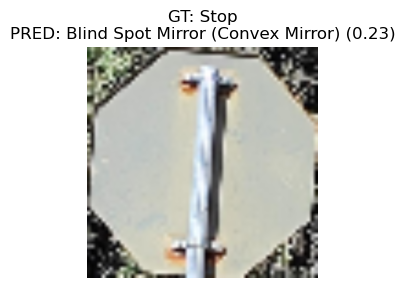

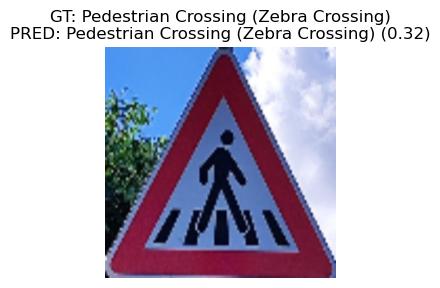

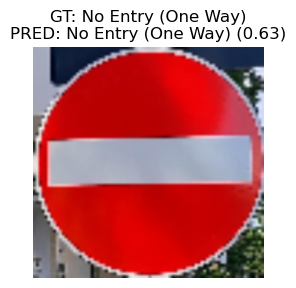

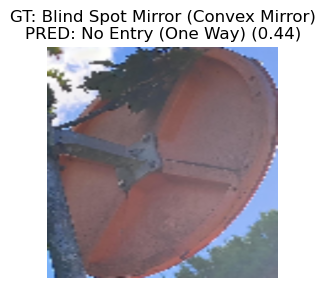

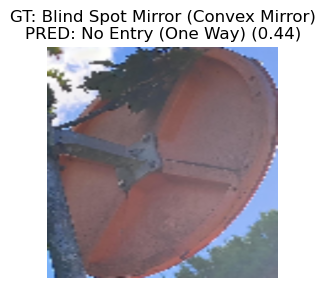

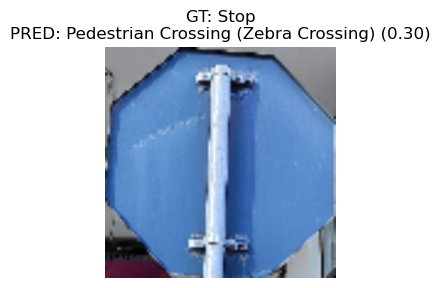

In [121]:
import matplotlib.pyplot as plt
import numpy as np

classifier.eval()
confusion = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=int)

with torch.no_grad():
    for crops, labels in val_loader:
        crops = crops.to(device)
        labels = labels.to(device)

        feats = feature_extractor(crops)
        preds = classifier(feats).argmax(dim=1)

        for g, p in zip(labels, preds):
            confusion[g.item(), p.item()] += 1

print("\nPer-class accuracy:")
for i in range(NUM_CLASSES):
    acc = confusion[i,i] / max(confusion[i].sum(), 1)
    print(f"{CLASS_NAMES[i+1]:<40}: {acc*100:.2f}%")

# Visualise
for i in range(6):
    crop, label = val_cls_ds[i]
    crop_t = crop.unsqueeze(0).to(device)

    with torch.no_grad():
        feat = feature_extractor(crop_t)
        logits = classifier(feat)
        prob = torch.softmax(logits, dim=1)
        pred = prob.argmax(dim=1).item()
        conf = prob.max().item()

    plt.figure(figsize=(3,3))
    plt.imshow(crop.permute(1,2,0))
    plt.title(
        f"GT: {CLASS_NAMES[label+1]}\n"
        f"PRED: {CLASS_NAMES[pred+1]} ({conf:.2f})"
    )
    plt.axis("off")
    plt.show()
